In [5]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import itertools


universe = [
    # Semiconductors / equipment / EDA
    "NVDA","AMD","AVGO","MU","AMAT","LRCX","KLAC","ADI","TXN","INTC",
    "QCOM","MRVL","NXPI","MCHP","ON","MPWR","TER","ENTG","SWKS","LSCC",
    "RMBS","QRVO","COHR","SYNA","IPGP","ALGM","CRUS","DIOD","FORM","POWI",
    "AEIS","SITM","MKSI","AMKR","ASML","TSM","SNPS","CDNS","STM",

    # Software / cloud / data / dev tools
    "MSFT","ORCL","CRM","NOW","ADBE","INTU","ADSK","DDOG","MDB","SNOW",
    "HUBS","SHOP","TEAM","GTLB","ESTC","PATH","CFLT","DOCN","AI","WK",
    "BOX","DBX","NTAP","WDAY","FICO","ROP","U","ZI","TWLO","PAYC",
    "VEEV","ANSS","MANH","BILL","PCOR","DT","APP","PLTR",

    # Cybersecurity / networking / infrastructure software
    "CRWD","PANW","FTNT","NET","ZS","OKTA","CHKP","FFIV","AKAM","CSCO",
    "ANET","GEN","QLYS","VRNS","TENB","RDWR","ATEN","NTCT","CVLT","RPD",
    "LDOS","BAH","IBM","JNPR","CIEN"
]

In [16]:
# Parameters
pca_factors = 5

In [3]:
print(f"Number of tickers in universe: {len(universe)}")

start_date = "2018-01-01"
end_date = None  

raw = yf.download(
    tickers=universe,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True
)

prices = raw["Close"].copy()

# sort dates and columns
prices = prices.sort_index()
prices = prices.reindex(sorted(prices.columns), axis=1)

# drop columns that are completely missing
prices = prices.dropna(axis=1, how="all")
min_obs = 252
mask = prices.notna().sum() >= min_obs
prices = prices.loc[:, mask]

Number of tickers in universe: 102


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ANSS"}}}
$ZI: possibly delisted; no timezone found
$ANSS: possibly delisted; no timezone found
$JNPR: possibly delisted; no timezone found

3 Failed downloads:
['ZI', 'ANSS', 'JNPR']: possibly delisted; no timezone found


In [ ]:
log_prices = np.log(prices)
returns = log_prices.diff().dropna() # Log Returns

mu = returns.mean(axis=0)
sigma = returns.std(axis=0, ddof=0) # ddof makes it a population var not a sample var

valid = sigma > 0
returns = returns.loc[:, valid]
mu = mu[valid]
sigma[valid]

r_stand = (returns - mu) / sigma  # Normalized returns needed for pca

print("Prices shape:", prices.shape)
print("Returns shape:", returns.shape)
print("Standardized returns shape:", r_stand.shape)

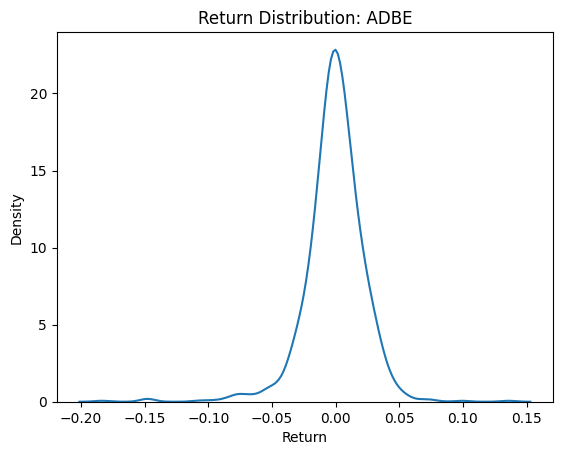

In [13]:
plt.figure()
sns.kdeplot(returns.iloc[:,0])
plt.title(f"Return Distribution: {returns.columns[0]}")
plt.xlabel("Return")
plt.ylabel("Density")
plt.show()

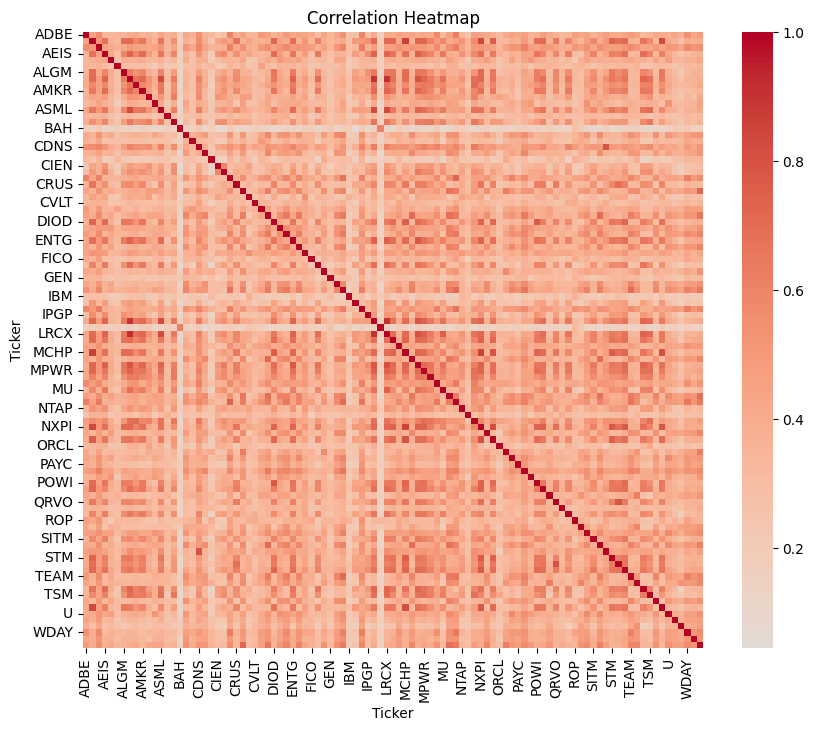

In [14]:
corr = r_stand.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

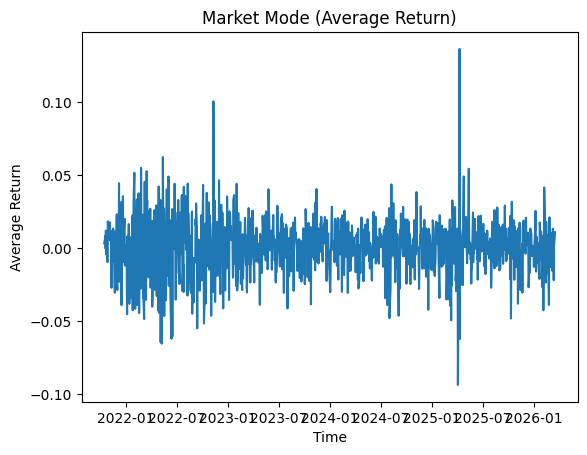

In [15]:
market_mode = returns.mean(axis=1)

plt.figure()
plt.plot(market_mode)
plt.title("Market Mode (Average Return)")
plt.xlabel("Time")
plt.ylabel("Average Return")
plt.show()

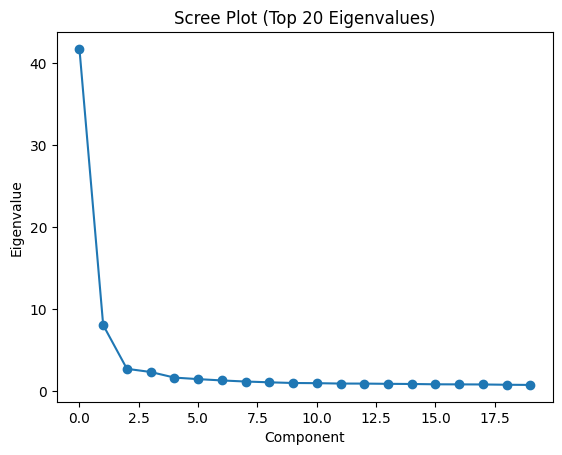

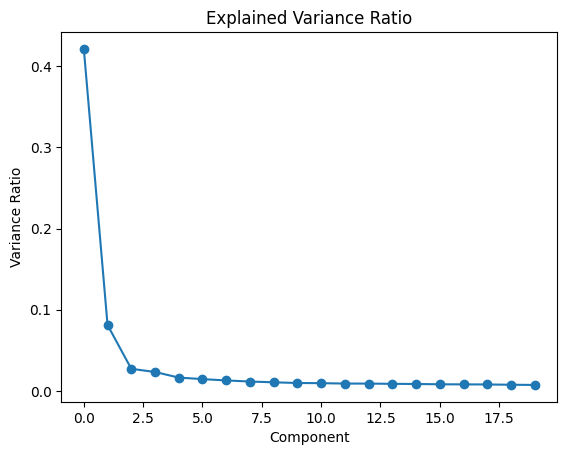

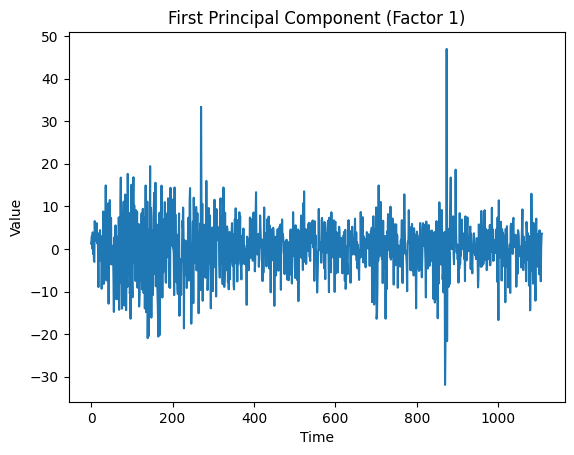

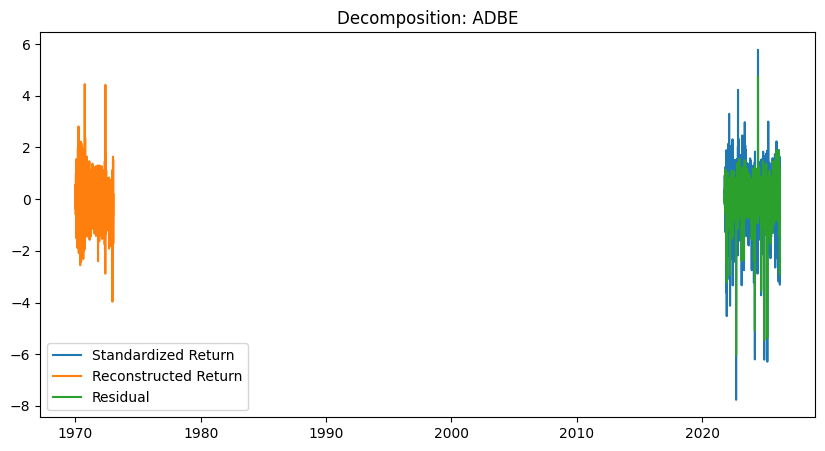

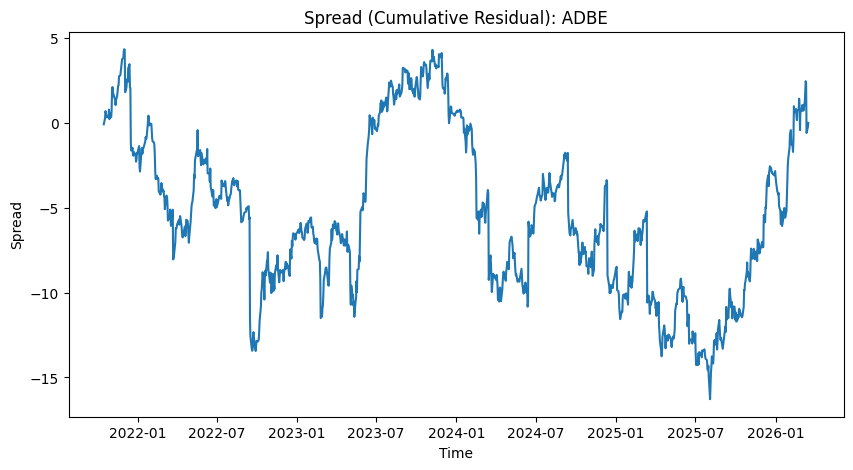

In [25]:


# -------------------------
# 1. Covariance matrix
# -------------------------
T = r_stand.shape[0]
C = (r_stand.T @ r_stand) / T   # (N x N)

# -------------------------
# 2. Eigen decomposition
# -------------------------
eigvals, eigvecs = np.linalg.eigh(C)  # symmetric → eigh

# sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# -------------------------
# 3. Choose number of factors
# -------------------------
k = 5
Lambda = eigvecs[:, :k]   # (N x k)

# -------------------------
# 4. Compute factor time series
# -------------------------
F = r_stand.values @ Lambda   # (T x k)

# -------------------------
# 5. Reconstruct returns
# -------------------------
R_hat = F @ Lambda.T          # (T x N)

# -------------------------
# 6. Residuals (THIS IS KEY)
# -------------------------
epsilon = r_stand.values - R_hat   # (T x N)

# convert back to DataFrame
epsilon = pd.DataFrame(epsilon, index=r_stand.index, columns=r_stand.columns)

# -------------------------
# 7. Build spreads (cumulative residuals)
# -------------------------
spreads = epsilon.cumsum()

# -------------------------
# 8. Scree plot (eigenvalues)
# -------------------------
plt.figure()
plt.plot(eigvals[:20], marker='o')
plt.title("Scree Plot (Top 20 Eigenvalues)")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.show()

# -------------------------
# 9. Explained variance ratio
# -------------------------
explained_var = eigvals / eigvals.sum()

plt.figure()
plt.plot(explained_var[:20], marker='o')
plt.title("Explained Variance Ratio")
plt.xlabel("Component")
plt.ylabel("Variance Ratio")
plt.show()

# -------------------------
# 10. First factor time series
# -------------------------
plt.figure()
plt.plot(F[:, 0])
plt.title("First Principal Component (Factor 1)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

# -------------------------
# 11. Example asset reconstruction
# -------------------------
asset = r_stand.columns[0]

plt.figure(figsize=(10,5))
plt.plot(r_stand[asset], label="Standardized Return")
plt.plot(R_hat[:, 0], label="Reconstructed Return")
plt.plot(epsilon[asset], label="Residual")
plt.legend()
plt.title(f"Decomposition: {asset}")
plt.show()

# -------------------------
# 12. Spread (THIS IS y_t)
# -------------------------
plt.figure(figsize=(10,5))
plt.plot(spreads[asset])
plt.title(f"Spread (Cumulative Residual): {asset}")
plt.xlabel("Time")
plt.ylabel("Spread")
plt.show()

ADBE: ADF=-2.292, p=0.17451
ADI: ADF=-2.337, p=0.16041
ADSK: ADF=-2.421, p=0.13589
AEIS: ADF=-2.295, p=0.17360
AI: ADF=-1.394, p=0.58537
AKAM: ADF=-1.623, p=0.47096
ALGM: ADF=-2.115, p=0.23856
AMAT: ADF=-2.790, p=0.05968
AMD: ADF=-3.222, p=0.01874
AMKR: ADF=-2.010, p=0.28242


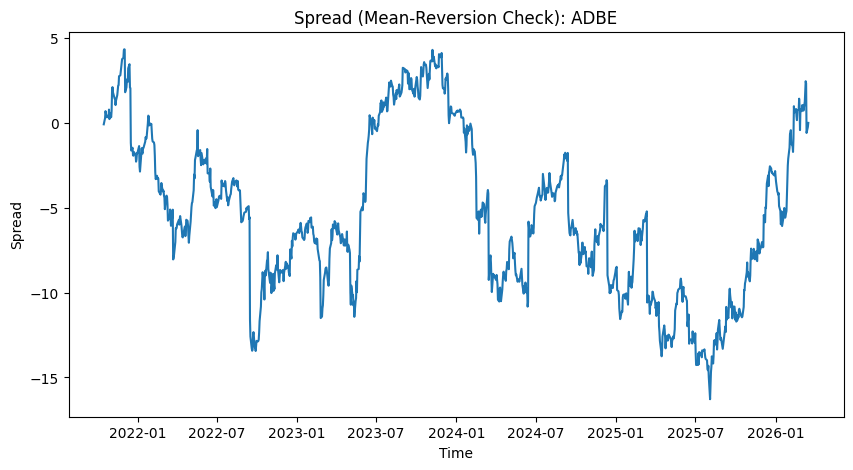

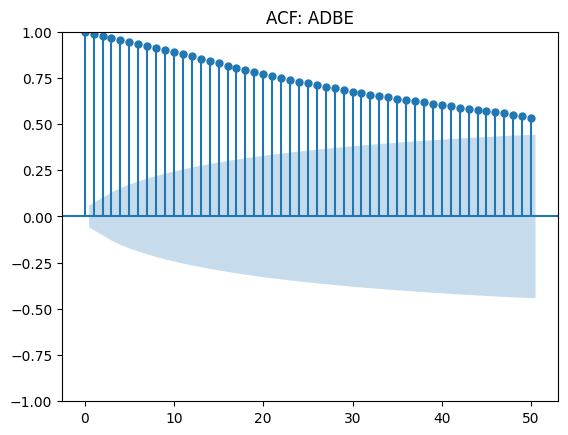

Estimated B (persistence): 0.9959
|B| < 1 ? YES (mean reverting)


In [26]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# 1. Pick sample assets to test
# -------------------------
test_assets = spreads.columns[:10]  # test first 10

results = {}

# -------------------------
# 2. ADF test
# -------------------------
for asset in test_assets:
    y = spreads[asset].dropna()
    adf_stat, pval, _, _, _, _ = adfuller(y)
    
    results[asset] = {
        "ADF Statistic": adf_stat,
        "p-value": pval
    }

# print results
for k, v in results.items():
    print(f"{k}: ADF={v['ADF Statistic']:.3f}, p={v['p-value']:.5f}")

# -------------------------
# 3. Plot example spread
# -------------------------
asset = test_assets[0]

plt.figure(figsize=(10,5))
plt.plot(spreads[asset])
plt.title(f"Spread (Mean-Reversion Check): {asset}")
plt.xlabel("Time")
plt.ylabel("Spread")
plt.show()

# -------------------------
# 4. Autocorrelation (ACF)
# -------------------------
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(spreads[asset], lags=50)
plt.title(f"ACF: {asset}")
plt.show()

# -------------------------
# 5. Estimate AR(1) manually (for intuition)
# -------------------------
y = spreads[asset].dropna().values

y_lag = y[:-1]
y_curr = y[1:]

# OLS estimate of B
B_hat = np.sum(y_lag * y_curr) / np.sum(y_lag**2)

print(f"Estimated B (persistence): {B_hat:.4f}")
print(f"|B| < 1 ? {'YES (mean reverting)' if abs(B_hat) < 1 else 'NO'}")

A_hat = 0.051192
B_hat = 0.981390
Q (process variance)     = 0.197068
R (observation variance) = 0.197068


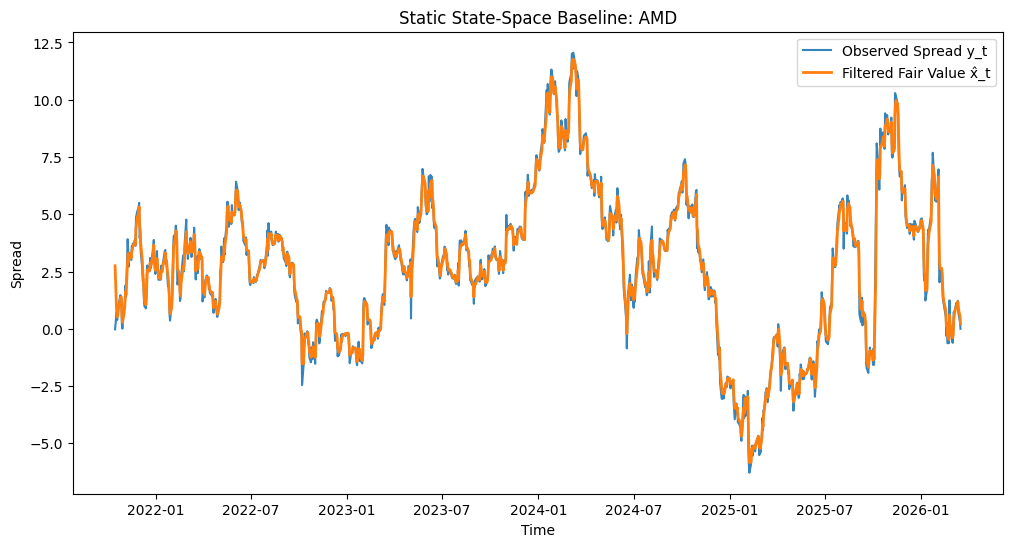

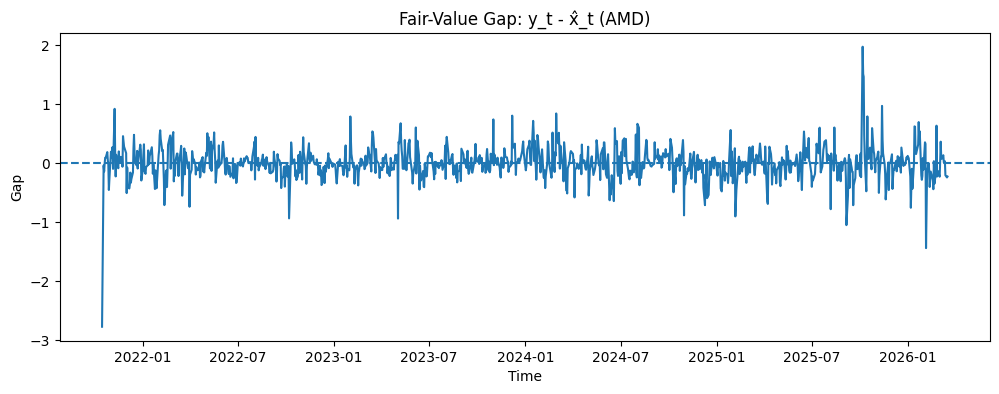

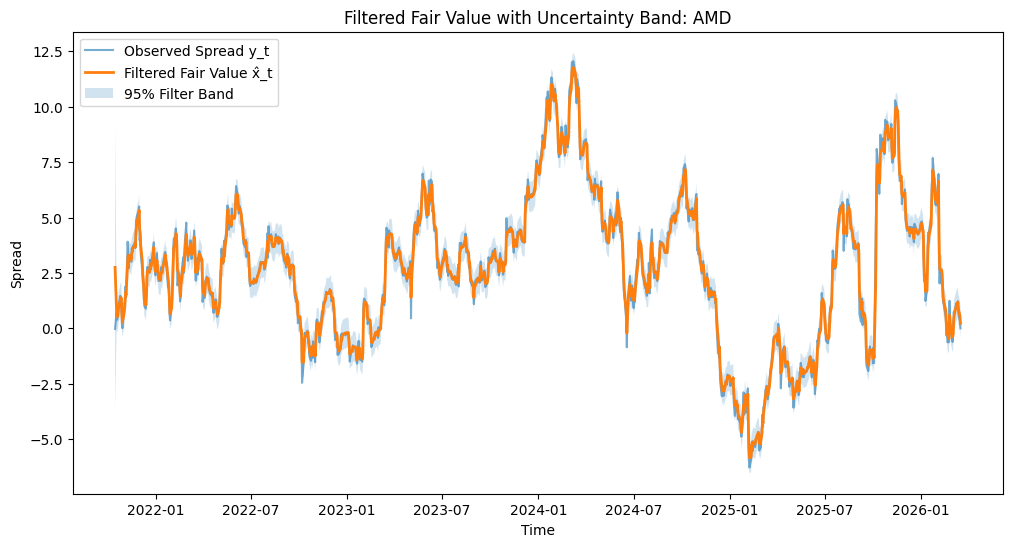

Equilibrium mean A/(1-B) = 2.750776

First rows:
                   y    x_fair    x_pred       gap  kalman_gain     P_filt
Date                                                                      
2021-10-15 -0.023233  2.750776  0.000000 -2.774009     0.000000  10.689191
2021-10-18  0.717711  0.755193  2.750776 -0.037482     0.981564   0.193435
2021-10-19  0.384221  0.522781  0.792331 -0.138560     0.660484   0.130160
2021-10-20  0.567051  0.565986  0.564244  0.001065     0.620656   0.122312
2021-10-21  0.850589  0.756684  0.606645  0.093905     0.615054   0.121208


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# -------------------------
# 1. Pick one spread
# -------------------------
asset = "AMD"   # change if you want another asset
y = spreads[asset].dropna().copy()

# -------------------------
# 2. Estimate static AR(1): y_t = A + B y_{t-1} + u_t
# -------------------------
y_lag = y.shift(1).dropna()
y_curr = y.iloc[1:]

X = sm.add_constant(y_lag.values)
ar1_model = sm.OLS(y_curr.values, X).fit()

A_hat = ar1_model.params[0]
B_hat = ar1_model.params[1]

print(f"A_hat = {A_hat:.6f}")
print(f"B_hat = {B_hat:.6f}")

# -------------------------
# 3. Estimate observation / process noise
# -------------------------
# AR(1) fitted residual variance as a starting point
u = ar1_model.resid
var_u = np.var(u, ddof=0)

# Split total noise into:
# Q = process variance
# R = observation variance
#
# Simple baseline split:
Q = 0.5 * var_u
R = 0.5 * var_u

print(f"Q (process variance)     = {Q:.6f}")
print(f"R (observation variance) = {R:.6f}")

# -------------------------
# 4. Kalman filter
# State: x_t = A + B x_{t-1} + eps_t
# Obs:   y_t = x_t + omega_t
# -------------------------
n = len(y)
y_vals = y.values

x_pred = np.zeros(n)   # x_{t|t-1}
P_pred = np.zeros(n)   # Var(x_{t|t-1})

x_filt = np.zeros(n)   # x_{t|t}
P_filt = np.zeros(n)   # Var(x_{t|t})

K = np.zeros(n)        # Kalman gain

# -------------------------
# 5. Initialize
# -------------------------
# Use unconditional mean if |B|<1, else first observation
if abs(B_hat) < 0.999:
    x_filt[0] = A_hat / (1 - B_hat)
else:
    x_filt[0] = y_vals[0]

P_filt[0] = np.var(y_vals, ddof=0)

# -------------------------
# 6. Recursive filter
# -------------------------
for t in range(1, n):
    # Predict
    x_pred[t] = A_hat + B_hat * x_filt[t - 1]
    P_pred[t] = (B_hat**2) * P_filt[t - 1] + Q

    # Update
    K[t] = P_pred[t] / (P_pred[t] + R)
    x_filt[t] = x_pred[t] + K[t] * (y_vals[t] - x_pred[t])
    P_filt[t] = (1 - K[t]) * P_pred[t]

# -------------------------
# 7. Residual / fair-value gap
# -------------------------
gap = y_vals - x_filt

# -------------------------
# 8. Put into DataFrame
# -------------------------
kf_df = pd.DataFrame({
    "y": y_vals,
    "x_fair": x_filt,
    "x_pred": x_pred,
    "gap": gap,
    "kalman_gain": K,
    "P_filt": P_filt
}, index=y.index)

# -------------------------
# 9. Plot observed spread vs filtered fair value
# -------------------------
plt.figure(figsize=(12, 6))
plt.plot(kf_df.index, kf_df["y"], label="Observed Spread y_t", alpha=0.9)
plt.plot(kf_df.index, kf_df["x_fair"], label="Filtered Fair Value x̂_t", linewidth=2)
plt.title(f"Static State-Space Baseline: {asset}")
plt.xlabel("Time")
plt.ylabel("Spread")
plt.legend()
plt.show()

# -------------------------
# 10. Plot residual gap
# -------------------------
plt.figure(figsize=(12, 4))
plt.plot(kf_df.index, kf_df["gap"])
plt.axhline(0, linestyle="--")
plt.title(f"Fair-Value Gap: y_t - x̂_t ({asset})")
plt.xlabel("Time")
plt.ylabel("Gap")
plt.show()

# -------------------------
# 11. Optional: uncertainty bands
# -------------------------
band = 1.96 * np.sqrt(kf_df["P_filt"].values)

plt.figure(figsize=(12, 6))
plt.plot(kf_df.index, kf_df["y"], label="Observed Spread y_t", alpha=0.6)
plt.plot(kf_df.index, kf_df["x_fair"], label="Filtered Fair Value x̂_t", linewidth=2)
plt.fill_between(
    kf_df.index,
    kf_df["x_fair"] - band,
    kf_df["x_fair"] + band,
    alpha=0.2,
    label="95% Filter Band"
)
plt.title(f"Filtered Fair Value with Uncertainty Band: {asset}")
plt.xlabel("Time")
plt.ylabel("Spread")
plt.legend()
plt.show()

# -------------------------
# 12. Print useful summary
# -------------------------
if abs(B_hat) < 1:
    mu_eq = A_hat / (1 - B_hat)
    print(f"Equilibrium mean A/(1-B) = {mu_eq:.6f}")
else:
    print("Equilibrium mean not defined because |B_hat| >= 1")

print("\nFirst rows:")
print(kf_df.head())

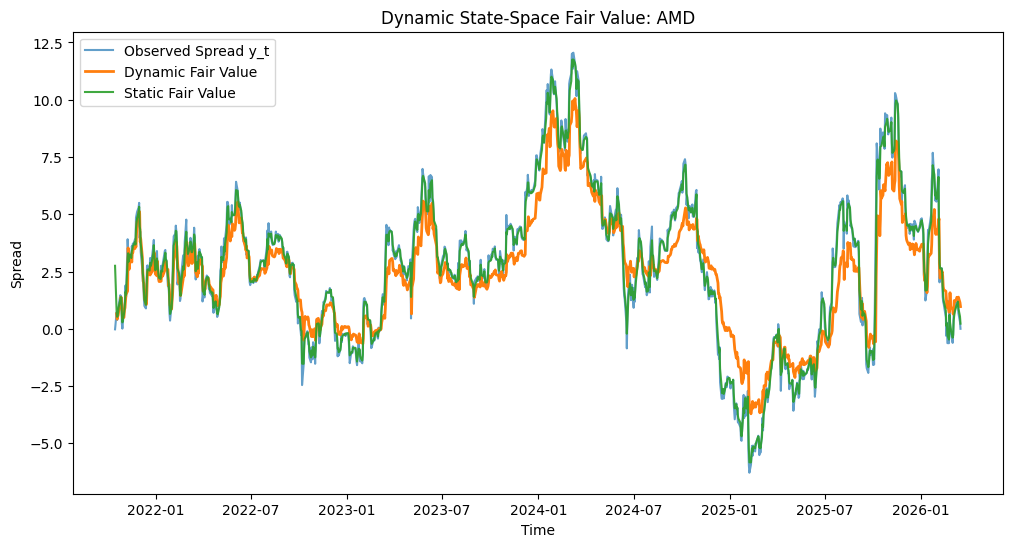

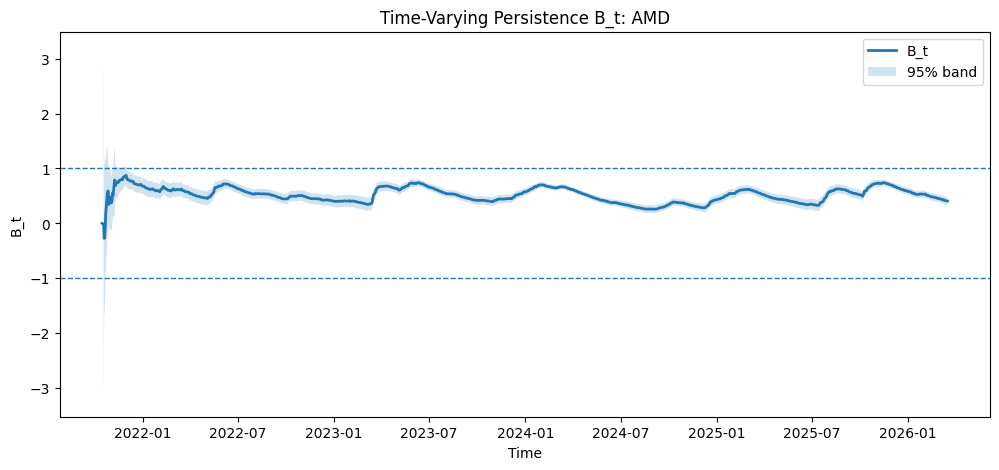

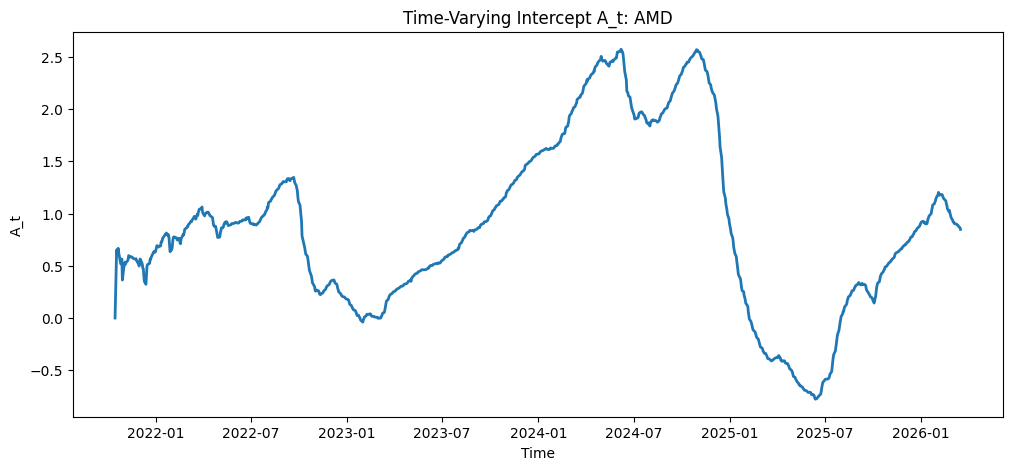

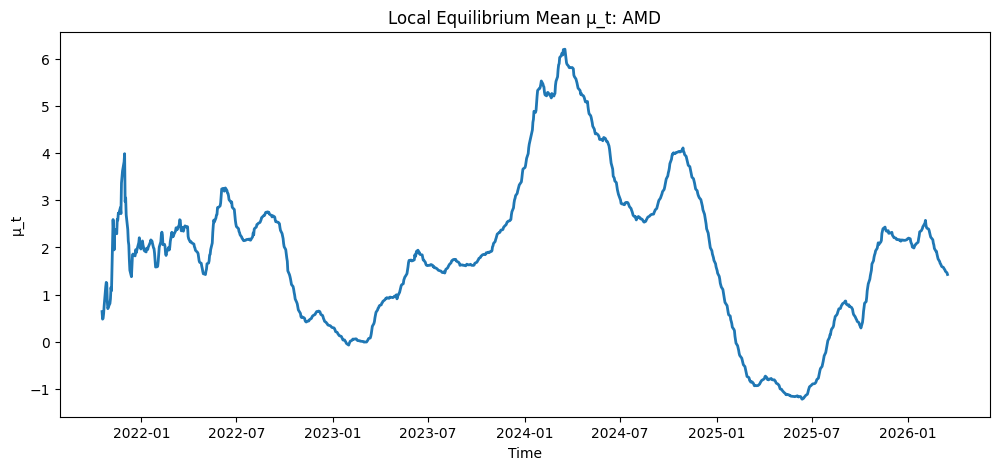

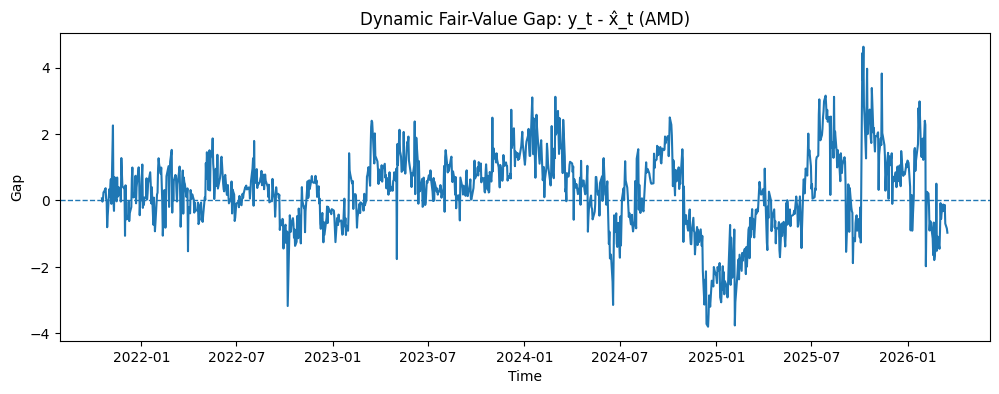

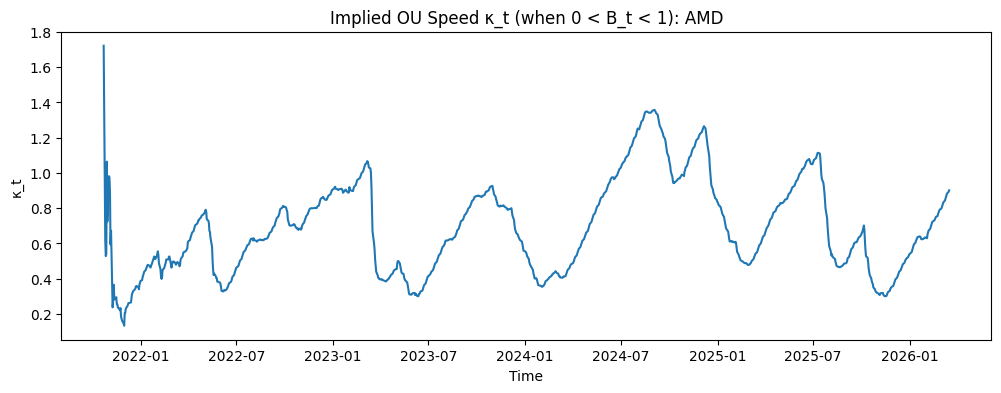

Asset: AMD

Last 5 rows:
                       y       A_t       B_t  fair_value  forecast  \
Date                                                                 
2026-03-11  1.112038e+00  0.891396  0.421863    1.336742  1.340362   
2026-03-12  1.219234e+00  0.889242  0.417640    1.353674  1.355832   
2026-03-13  6.861181e-01  0.878207  0.413364    1.382195  1.393351   
2026-03-16  3.008228e-01  0.864451  0.409502    1.145418  1.158987   
2026-03-17  2.026157e-14  0.848379  0.406040    0.970525  0.986407   

            forecast_error  sigma2_scale     mu_eq     kappa  B_lower_95  \
Date                                                                       
2026-03-11       -0.228324      1.479388  1.541842  0.863076    0.351240   
2026-03-12       -0.136599      1.478069  1.526963  0.873135    0.346682   
2026-03-13       -0.707233      1.477179  1.497023  0.883426    0.342060   
2026-03-16       -0.858165      1.476500  1.463936  0.892813    0.337848   
2026-03-17       -0.986407  

In [28]:
# ==========================================
# STEP 7–8 — DYNAMIC PAPER MODEL
# y_t = A_t + B_t y_{t-1} + eps_t
# [A_t, B_t]' = Phi [A_{t-1}, B_{t-1}]' + nu_t
#
# Implements the recursive Bayesian / discount-factor filter
# from the paper for ONE spread.
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1. Pick one spread
# -------------------------
asset = "AMD"   # change if needed
y = spreads[asset].dropna().copy()
y_vals = y.values
dates = y.index
T = len(y_vals)

# -------------------------
# 2. Hyperparameters
# -------------------------
# State persistence
phi1 = 1.00     # often fixed near 1 for A_t
phi2 = 0.99     # B_t persistence

# Discount factors
delta1 = 0.99   # how fast A_t adapts
delta2 = 0.97   # how fast B_t adapts

# Initial priors
m1 = np.array([0.0, 0.0])          # prior mean of [A_1, B_1]
P1 = np.eye(2) * 10.0              # diffuse prior covariance
n1 = 3.0                           # inverse-gamma dof
d1 = 1.0                           # inverse-gamma scale

Phi = np.diag([phi1, phi2])

# -------------------------
# 3. Storage
# -------------------------
m_store = np.zeros((T, 2))         # posterior mean of [A_t, B_t]
P_store = np.zeros((T, 2, 2))      # posterior covariance
S_store = np.zeros(T)              # sigma^2 estimate scale
Q_store = np.zeros(T)              # one-step forecast variance (scaled)
e_store = np.zeros(T)              # forecast error
f_store = np.full(T, np.nan)       # fitted / predicted spread
xfair_store = np.full(T, np.nan)   # filtered fair value
mu_eq_store = np.full(T, np.nan)   # A_t / (1 - B_t)
kappa_store = np.full(T, np.nan)   # -ln(B_t) if 0 < B_t < 1
lower_B = np.full(T, np.nan)       # 95% band for B_t
upper_B = np.full(T, np.nan)
K_store = np.zeros((T, 2))         # Kalman gain vector
valid_mr = np.zeros(T, dtype=bool) # local mean-reversion flag

# -------------------------
# 4. Initialize
# -------------------------
m_prev = m1.copy()
P_prev = P1.copy()
n_prev = n1
d_prev = d1
S_prev = d_prev / n_prev

m_store[0] = m_prev
P_store[0] = P_prev
S_store[0] = S_prev

# -------------------------
# 5. Recursive filter
# -------------------------
for t in range(1, T):
    # F_t = [1, y_{t-1}]'
    F_t = np.array([1.0, y_vals[t - 1]])

    # Component discounting:
    # V_t chosen so prior variance inflates by 1/delta_j
    V_t = np.array([
        [((1.0 - delta1) / delta1) * (phi1 ** 2) * P_prev[0, 0], 0.0],
        [0.0, ((1.0 - delta2) / delta2) * (phi2 ** 2) * P_prev[1, 1]]
    ])

    # Prior
    a_t = Phi @ m_prev
    R_t = Phi @ P_prev @ Phi.T + V_t

    # One-step forecast
    f_t = F_t @ a_t
    Q_t = F_t @ R_t @ F_t + 1.0
    e_t = y_vals[t] - f_t

    # Kalman gain
    K_t = (R_t @ F_t) / Q_t

    # Posterior mean/covariance
    m_t = a_t + K_t * e_t
    P_t = R_t - np.outer(K_t, K_t) * Q_t

    # Variance update
    r_t = y_vals[t] - (F_t @ m_t)
    n_t = n_prev + 1.0
    d_t = d_prev + r_t * e_t
    S_t = d_t / n_t

    # Store
    m_store[t] = m_t
    P_store[t] = P_t
    S_store[t] = S_t
    Q_store[t] = Q_t
    e_store[t] = e_t
    f_store[t] = f_t
    xfair_store[t] = F_t @ m_t

    A_t = m_t[0]
    B_t = m_t[1]

    # Local equilibrium mean
    if abs(1.0 - B_t) > 1e-6:
        mu_eq_store[t] = A_t / (1.0 - B_t)

    # OU speed only if standard OU mapping is valid
    if 0.0 < B_t < 1.0:
        kappa_store[t] = -np.log(B_t)

    # 95% interval for B_t
    b_std = np.sqrt(max(P_t[1, 1] * S_t, 0.0))
    lower_B[t] = B_t - 1.96 * b_std
    upper_B[t] = B_t + 1.96 * b_std

    valid_mr[t] = abs(B_t) < 1.0

    K_store[t] = K_t

    # Roll
    m_prev = m_t
    P_prev = P_t
    n_prev = n_t
    d_prev = d_t
    S_prev = S_t

# -------------------------
# 6. Results DataFrame
# -------------------------
dyn_df = pd.DataFrame({
    "y": y_vals,
    "A_t": m_store[:, 0],
    "B_t": m_store[:, 1],
    "fair_value": xfair_store,
    "forecast": f_store,
    "forecast_error": e_store,
    "sigma2_scale": S_store,
    "mu_eq": mu_eq_store,
    "kappa": kappa_store,
    "B_lower_95": lower_B,
    "B_upper_95": upper_B,
    "mean_reverting": valid_mr
}, index=dates)

dyn_df["gap"] = dyn_df["y"] - dyn_df["fair_value"]

# -------------------------
# 7. Optional comparison to static model
# -------------------------
# If you already created kf_df from Step 6, this will plot it.
has_static = "kf_df" in globals() and isinstance(kf_df, pd.DataFrame)

# -------------------------
# 8. Plot: dynamic fair value vs observed spread
# -------------------------
plt.figure(figsize=(12, 6))
plt.plot(dyn_df.index, dyn_df["y"], label="Observed Spread y_t", alpha=0.7)
plt.plot(dyn_df.index, dyn_df["fair_value"], label="Dynamic Fair Value", linewidth=2)
if has_static and asset in spreads.columns and len(kf_df) == len(dyn_df):
    plt.plot(kf_df.index, kf_df["x_fair"], label="Static Fair Value", linewidth=1.5, alpha=0.9)
plt.title(f"Dynamic State-Space Fair Value: {asset}")
plt.xlabel("Time")
plt.ylabel("Spread")
plt.legend()
plt.show()

# -------------------------
# 9. Plot: B_t with mean-reversion boundaries
# -------------------------
plt.figure(figsize=(12, 5))
plt.plot(dyn_df.index, dyn_df["B_t"], label="B_t", linewidth=2)
plt.fill_between(
    dyn_df.index,
    dyn_df["B_lower_95"],
    dyn_df["B_upper_95"],
    alpha=0.2,
    label="95% band"
)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.axhline(-1.0, linestyle="--", linewidth=1)
plt.title(f"Time-Varying Persistence B_t: {asset}")
plt.xlabel("Time")
plt.ylabel("B_t")
plt.legend()
plt.show()

# -------------------------
# 10. Plot: A_t
# -------------------------
plt.figure(figsize=(12, 5))
plt.plot(dyn_df.index, dyn_df["A_t"], linewidth=2)
plt.title(f"Time-Varying Intercept A_t: {asset}")
plt.xlabel("Time")
plt.ylabel("A_t")
plt.show()

# -------------------------
# 11. Plot: local equilibrium mean mu_t = A_t / (1 - B_t)
# -------------------------
plt.figure(figsize=(12, 5))
plt.plot(dyn_df.index, dyn_df["mu_eq"], linewidth=2)
plt.title(f"Local Equilibrium Mean μ_t: {asset}")
plt.xlabel("Time")
plt.ylabel("μ_t")
plt.show()

# -------------------------
# 12. Plot: fair-value gap
# -------------------------
plt.figure(figsize=(12, 4))
plt.plot(dyn_df.index, dyn_df["gap"])
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.title(f"Dynamic Fair-Value Gap: y_t - x̂_t ({asset})")
plt.xlabel("Time")
plt.ylabel("Gap")
plt.show()

# -------------------------
# 13. Plot: OU speed kappa_t
# -------------------------
plt.figure(figsize=(12, 4))
plt.plot(dyn_df.index, dyn_df["kappa"])
plt.title(f"Implied OU Speed κ_t (when 0 < B_t < 1): {asset}")
plt.xlabel("Time")
plt.ylabel("κ_t")
plt.show()

# -------------------------
# 14. Summary stats
# -------------------------
print(f"Asset: {asset}")
print("\nLast 5 rows:")
print(dyn_df.tail())

print("\nMean of B_t:", dyn_df["B_t"].mean())
print("Fraction of time |B_t| < 1:", dyn_df["mean_reverting"].mean())

valid_ou = dyn_df["kappa"].dropna()
if len(valid_ou) > 0:
    print("Average κ_t:", valid_ou.mean())

print("\nLatest values:")
print("A_t       =", dyn_df['A_t'].iloc[-1])
print("B_t       =", dyn_df['B_t'].iloc[-1])
print("mu_eq     =", dyn_df['mu_eq'].iloc[-1])
print("fair_value=", dyn_df['fair_value'].iloc[-1])
print("gap       =", dyn_df['gap'].iloc[-1])